
Solving MILP model (This may take a moment due to integer constraints)...

✅ Status: OPTIMAL
💰 Total Objective Value: $2,958,359.50
⏱️ Total Project Makespan: 133.4 Days

--- Project Schedule Snippet ---


,Task_ID,Employee_ID,Start_Day,Finish_Day,Duration_Days
0,P001_T1,EXT_CONTRACTOR,0.000,50.000,50.000
2,P002_T1,E009,0.000,33.375,33.375
5,P003_T1,E015,0.000,78.125,78.125
6,P003_T2,E008,0.000,50.000,50.000
7,P004_T1,E022,0.000,15.625,15.625
9,P004_T3,E003,0.000,125.000,125.000
8,P004_T2,E024,15.625,93.750,78.125
3,P002_T2,E025,33.375,133.375,100.000
4,P002_T3,EXT_CONTRACTOR,33.375,41.750,8.375
1,P001_T2,E018,50.000,128.125,78.125



📊 Saved Corrected Gantt Chart to: 2026-04-25_18-23-48/gantt_chart_fixed.png


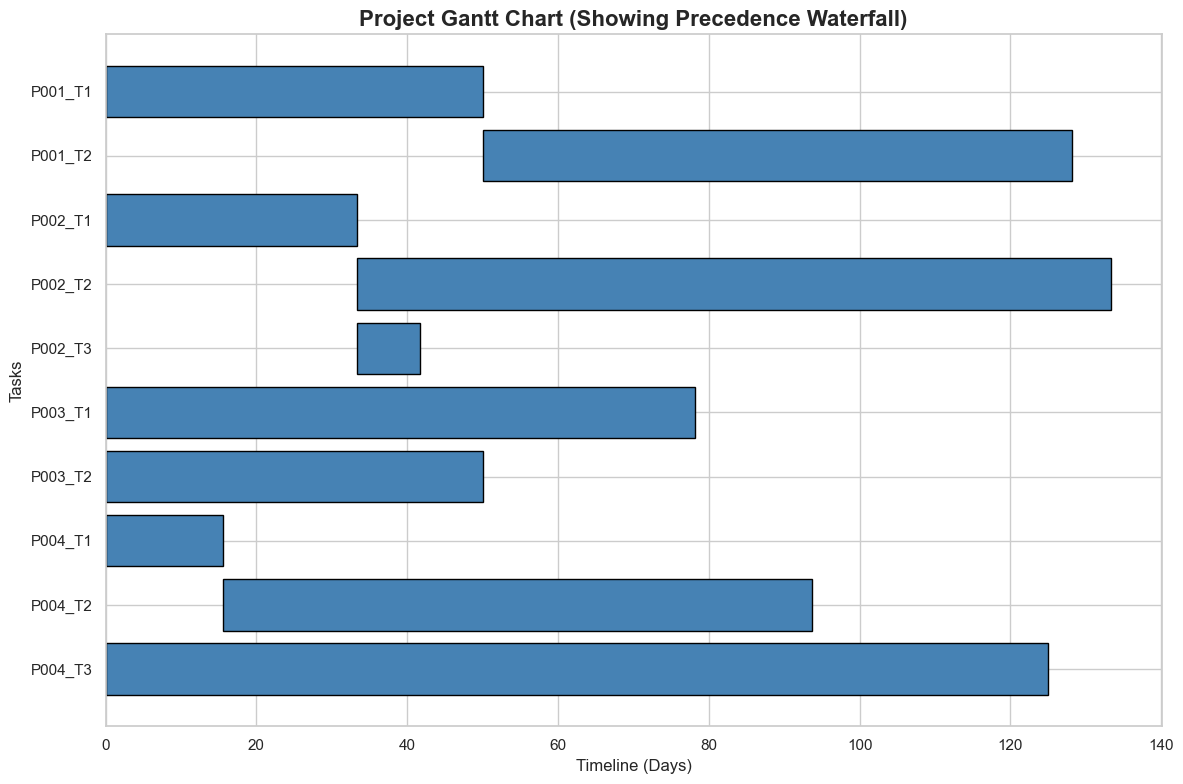

In [15]:
import pandas as pd
import json
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ==========================================
# 1. LOAD AND PREP DATA
# ==========================================
# UPDATE THIS PATH to your newly generated dataset folder
EXPORT_PATH = '2026-04-25_18-23-48' 

try:
    employees_df = pd.read_csv(f'{EXPORT_PATH}/employees.csv')
    tasks_df = pd.read_csv(f'{EXPORT_PATH}/tasks.csv')
except FileNotFoundError:
    print("Error: Could not find the CSVs.")
    raise

# Custom Parsers
def parse_skill_string(skill_str):
    if pd.isna(skill_str) or not isinstance(skill_str, str):
        return {}
    skill_dict = {}
    for item in skill_str.split('|'):
        if ':' in item:
            skill, level = item.split(':')
            skill_dict[skill.strip()] = int(level.strip())
    return skill_dict

def safe_json_load(val):
    try:
        return json.loads(val)
    except (TypeError, ValueError):
        return []

employees_df['Specific_Skills_Dict'] = employees_df['Specific_Skills'].apply(parse_skill_string)
tasks_df['Req_Dict'] = tasks_df['Skills_Needed'].apply(parse_skill_string) 
tasks_df['Predecessors_List'] = tasks_df['Predecessors'].apply(safe_json_load)

# Safety check for EXT_CONTRACTOR
if 'EXT_CONTRACTOR' not in employees_df['Employee_ID'].values:
    all_required_skills = set()
    for req_dict in tasks_df['Req_Dict']:
        all_required_skills.update(req_dict.keys())
    contractor_skills = {skill: 5 for skill in all_required_skills}
    contractor = pd.DataFrame([{
        'Employee_ID': 'EXT_CONTRACTOR',
        'Specific_Skills_Dict': contractor_skills,
        'Hourly_Cost': 5000,
        'Max_Hours': 999999
    }])
    employees_df = pd.concat([employees_df, contractor], ignore_index=True)


# ==========================================
# 2. VALID PAIRS & BOTTLENECK RHO (Soft Constraint)
# ==========================================
def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0: return 0.8  
    elif emp_level == task_level: return 1.0  
    elif emp_level > task_level: return 1.5  
    else: return 0.5  

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp['Specific_Skills_Dict']
    for _, task in tasks_df.iterrows():
        task_reqs = task['Req_Dict']
        skill_rhos = []
        missing_skills_count = 0
        
        for skill, req_level in task_reqs.items():
            emp_level = emp_skills.get(skill, 0)
            if emp_level == 0: missing_skills_count += 1
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        # Must have at least one relevant skill
        if missing_skills_count < len(task_reqs):
            overall_rho = min(skill_rhos)
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho


# ==========================================
# 3. BUILD THE MILP SOLVER (Phase 4: Time Edition)
# ==========================================
solver = pywraplp.Solver.CreateSolver('SCIP')

# --- VARIABLES ---
x = {} # Integer: Work hours
y = {} # Binary: Context switch assignment
M = 2080 
TAU_PENALTY = 20 

for (i, j) in valid_pairs:
    x[(i, j)] = solver.IntVar(0, solver.infinity(), f'x_{i}_{j}')
    y[(i, j)] = solver.BoolVar(f'y_{i}_{j}') 

# Time Variables (Continuous Days)
S = {} # Start Time
F = {} # Finish Time
for j in tasks_df['Task_ID']:
    S[j] = solver.NumVar(0, solver.infinity(), f'Start_{j}')
    F[j] = solver.NumVar(0, solver.infinity(), f'Finish_{j}')

C_max = solver.NumVar(0, solver.infinity(), 'Makespan') 

# --- CORE CONSTRAINTS ---
# 1. Big-M Linking: x_ij - M * y_ij <= 0
for (i, j) in valid_pairs:
    constraint = solver.Constraint(-solver.infinity(), 0, f"BigM_{i}_{j}")
    constraint.SetCoefficient(x[(i, j)], 1)
    constraint.SetCoefficient(y[(i, j)], -M)

# 2. Demand Satisfaction (Using Bottleneck Rho)
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        constraint.SetCoefficient(x[(i, j)], float(rho_dict[(i, j)]))

# 3. Capacity Limit (Work + Setup)
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(x[(i, j)], 1)
        constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)

# --- NEW TIME CONSTRAINTS ---
# 4. Duration: Finish - Start >= Sum(Work Hours / 8)
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(0, solver.infinity(), f"Duration_{j}")
    constraint.SetCoefficient(F[j], 1)
    constraint.SetCoefficient(S[j], -1)
    for i in capable_employees:
        constraint.SetCoefficient(x[(i, j)], -0.125) # 1/8 hours per day

# 5. Precedence: Start_j >= Finish_p
for _, task in tasks_df.iterrows():
    j = task['Task_ID']
    predecessors = task['Predecessors_List']
    for p in predecessors:
        constraint = solver.Constraint(0, solver.infinity(), f"Precedence_{p}_to_{j}")
        constraint.SetCoefficient(S[j], 1)
        constraint.SetCoefficient(F[p], -1)

# 6. Makespan Tracker: C_max >= Finish_j
for j in tasks_df['Task_ID']:
    constraint = solver.Constraint(0, solver.infinity(), f"Makespan_{j}")
    constraint.SetCoefficient(C_max, 1)
    constraint.SetCoefficient(F[j], -1)

# --- OBJECTIVE FUNCTION ---
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()

# Financial Cost (Wages + Setup)
for (i, j) in valid_pairs:
    wage = float(cost_dict[i])
    objective.SetCoefficient(x[(i, j)], wage)
    objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)

# Time Cost (Weight penalty for every day the project extends)
TIME_WEIGHT_PENALTY = 500  
objective.SetCoefficient(C_max, TIME_WEIGHT_PENALTY)

objective.SetMinimization()


# ==========================================
# 4. SOLVE & EXTRACT
# ==========================================
print("\nSolving MILP model (This may take a moment due to integer constraints)...")
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL")
    print(f"💰 Total Objective Value: ${solver.Objective().Value():,.2f}")
    print(f"⏱️ Total Project Makespan: {C_max.solution_value():.1f} Days")
    
    # Extract Task Schedule
    schedule_data = []
    for j in tasks_df['Task_ID']:
        schedule_data.append({
            'Task_ID': j,
            'Employee_ID': next((i for (i, t_id) in valid_pairs if t_id == j and x[(i, j)].solution_value() > 0), 'Unassigned'),
            'Start_Day': S[j].solution_value(),
            'Finish_Day': F[j].solution_value(),
            'Duration_Days': F[j].solution_value() - S[j].solution_value()
        })
    schedule_df = pd.DataFrame(schedule_data).sort_values(by='Start_Day')
    
    print("\n--- Project Schedule Snippet ---")
    display(schedule_df)

else:
    print("Solver failed. Status:", status)

# ==========================================
# 5. GANTT CHART VISUALIZATION (CORRECTED)
# ==========================================
if status == pywraplp.Solver.OPTIMAL:
    sns.set_theme(style="whitegrid")
    
    # FIX: Instead of taking the first 20 tasks of the whole dataset, 
    # let's select a few specific projects that have clear dependencies to prove it works.
    projects_to_show = ['P001_', 'P002_', 'P003_','P004_', 'P005_', 'P006_', 'P007_', 'P008_', 'P009_', 'P010_', 'P011_', 'P012_', 'P013_']  # Adjust as needed based on your Task_ID patterns
    
    # Filter the schedule to only show these projects
    plot_df = schedule_df[schedule_df['Task_ID'].str.contains('|'.join(projects_to_show))]
    
    # Sort backwards by Task_ID so they cascade nicely from top to bottom
    plot_df = plot_df.sort_values(by=['Task_ID'], ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw horizontal bars for each task
    for i, row in plot_df.iterrows():
        ax.barh(row['Task_ID'], row['Duration_Days'], left=row['Start_Day'], color='steelblue', edgecolor='black')

    plt.title('Project Gantt Chart (Showing Precedence Waterfall)', fontsize=16, fontweight='bold')
    plt.xlabel('Timeline (Days)', fontsize=12)
    plt.ylabel('Tasks', fontsize=12)
    plt.tight_layout()

    gantt_path = f"{EXPORT_PATH}/gantt_chart_fixed.png"
    plt.savefig(gantt_path, dpi=300)
    print(f"\n📊 Saved Corrected Gantt Chart to: {gantt_path}")
    plt.show()


Solving Time-Indexed MILP model with Horizon = 100 days...
This may take a while depending on data size...

✅ Status: OPTIMAL
💰 Total Objective Value: $3,780,160.00
⏱️ Total Project Makespan: 100 Days

--- Project Schedule ---


,Task_ID,Employee_ID,Start_Day,Finish_Day,Duration_Days
0,P001_T1,EXT_CONTRACTOR,-0.0,50.0,50.0
2,P002_T1,E009,-0.0,20.0,20.0
5,P003_T1,E007,-0.0,100.0,100.0
6,P003_T2,E008,-0.0,100.0,100.0
7,P004_T1,E005,-0.0,5.0,5.0
9,P004_T3,E003,-0.0,100.0,100.0
8,P004_T2,E006,5.0,100.0,95.0
3,P002_T2,E010,20.0,100.0,80.0
4,P002_T3,EXT_CONTRACTOR,20.0,100.0,80.0
1,P001_T2,E002,50.0,100.0,50.0



📊 Saved Corrected Gantt Chart to: 2026-04-25_18-23-48/gantt_chart_fixed.png


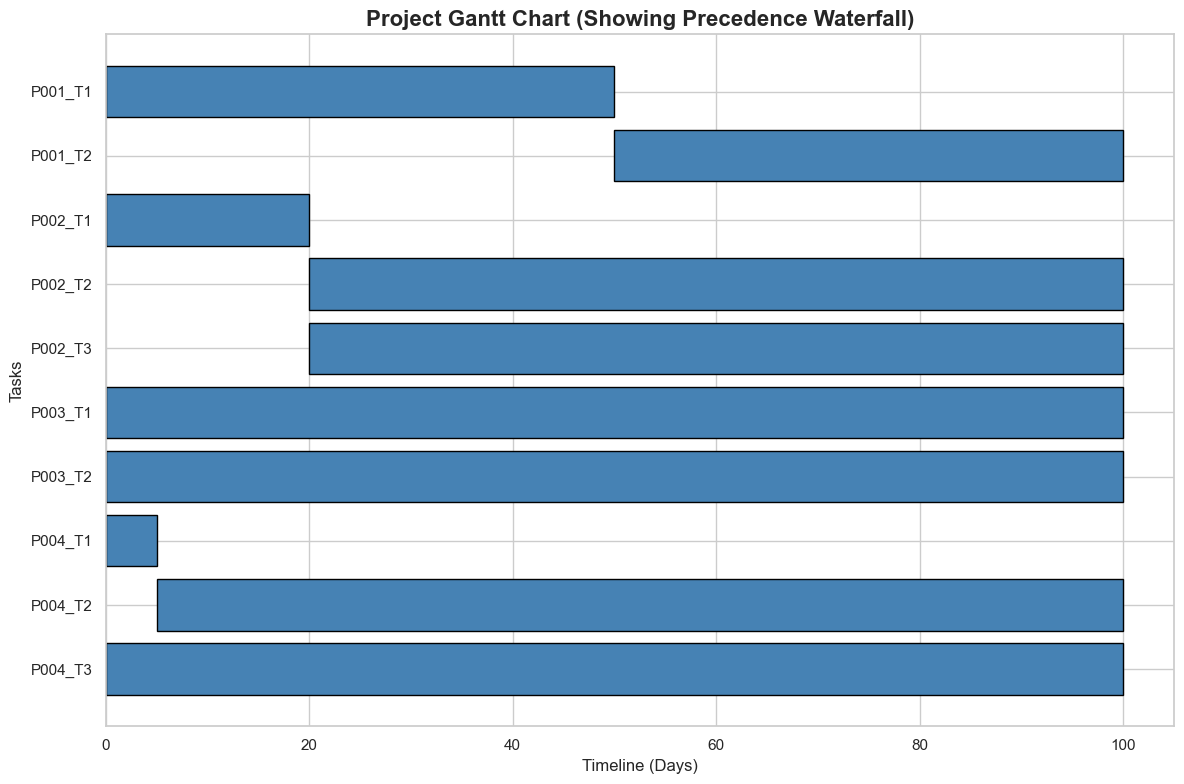

In [19]:
import pandas as pd
import json
from ortools.linear_solver import pywraplp

# ==========================================
# 1. DATA PREPARATION (Assumes Data is Loaded)
# ==========================================
# Make sure your employees_df and tasks_df are loaded here.
# tasks_df must have 'Hours_Needed', 'Task_ID', and 'Predecessors_List'
# employees_df must have 'Employee_ID', 'Hourly_Cost', 'Max_Hours'

# For this script to run, ensure you have parsed your skills into dictionaries:
# employees_df['Specific_Skills_Dict'] 
# tasks_df['Req_Dict']
# tasks_df['Predecessors_List'] 

# ==========================================
# 2. VALID PAIRS & BOTTLENECK RHO (Soft Constraint)
# ==========================================
def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0: return 0.2  
    elif emp_level == task_level: return 1.0  
    elif emp_level > task_level: return 1.5  
    else: return 0.5  

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp.get('Specific_Skills_Dict', {})
    for _, task in tasks_df.iterrows():
        task_reqs = task.get('Req_Dict', {})
        skill_rhos = []
        missing_skills_count = 0
        
        for skill, req_level in task_reqs.items():
            emp_level = emp_skills.get(skill, 0)
            if emp_level == 0: missing_skills_count += 1
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        # Must have at least one relevant skill
        if missing_skills_count < len(task_reqs):
            overall_rho = min(skill_rhos)
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho


# ==========================================
# 3. BUILD THE TIME-INDEXED MILP SOLVER
# ==========================================
solver = pywraplp.Solver.CreateSolver('SCIP')

# --- CONFIGURATION PARAMETERS ---
TIME_HORIZON = 100      # Max allowed days for the project to finish (KEEP THIS SMALL FOR TESTING)
HOURS_PER_DAY = 8      # Hours worked in a single day shift
TAU_PENALTY = 20       # Hours lost to context switching per task assignment
M_TIME = TIME_HORIZON + 1 
M_CAP = TIME_HORIZON + 1

# --- DECISION VARIABLES ---
y = {} # Binary: 1 if Employee i is assigned to Task j AT ALL
z = {} # Binary: 1 if Employee i works on Task j on Day t

for (i, j) in valid_pairs:
    y[(i, j)] = solver.BoolVar(f'y_{i}_{j}')
    for t in range(TIME_HORIZON):
        z[(i, j, t)] = solver.BoolVar(f'z_{i}_{j}_{t}')

# Time Variables (Integer Days)
S = {} # Start Day
F = {} # Finish Day
for j in tasks_df['Task_ID']:
    S[j] = solver.IntVar(0, TIME_HORIZON, f'Start_{j}')
    F[j] = solver.IntVar(0, TIME_HORIZON, f'Finish_{j}')

C_max = solver.IntVar(0, TIME_HORIZON, 'Makespan') 

# --- CONSTRAINTS ---

# 1. Assignment Linking: If z=1 on any day, y must be 1. 
# sum(z) <= M * y
for (i, j) in valid_pairs:
    constraint = solver.Constraint(-solver.infinity(), 0, f"Link_y_z_{i}_{j}")
    constraint.SetCoefficient(y[(i, j)], -M_CAP)
    for t in range(TIME_HORIZON):
        constraint.SetCoefficient(z[(i, j, t)], 1)

# 2. Concurrency Limit (NO DOUBLE BOOKING)
# An employee can only work on maximum 1 task per day.
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    for t in range(TIME_HORIZON):
        constraint = solver.Constraint(0, 1, f"Concurrency_{i}_{t}")
        for j in assigned_tasks:
            constraint.SetCoefficient(z[(i, j, t)], 1)

# 3. Demand Satisfaction
# sum(z * 8 hours * rho) >= Total Demand Hours
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        rho = rho_dict[(i, j)]
        for t in range(TIME_HORIZON):
            constraint.SetCoefficient(z[(i, j, t)], HOURS_PER_DAY * float(rho))

# 4. Total Capacity Limit
# sum(z * 8) + (y * setup_penalty) <= Max_Hours
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)
        for t in range(TIME_HORIZON):
            constraint.SetCoefficient(z[(i, j, t)], HOURS_PER_DAY)

# 5. Link Time Variables (S and F) to Daily Variables (z)
# If z_ijt = 1, then Start <= t, and Finish >= t + 1
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    for i in capable_employees:
        for t in range(TIME_HORIZON):
            # S_j <= t + M(1 - z)  ---> S_j + M * z <= t + M
            s_constraint = solver.Constraint(-solver.infinity(), t + M_TIME, f"Link_S_{i}_{j}_{t}")
            s_constraint.SetCoefficient(S[j], 1)
            s_constraint.SetCoefficient(z[(i, j, t)], M_TIME)
            
            # F_j >= (t + 1) * z  ---> F_j - (t+1)*z >= 0
            f_constraint = solver.Constraint(0, solver.infinity(), f"Link_F_{i}_{j}_{t}")
            f_constraint.SetCoefficient(F[j], 1)
            f_constraint.SetCoefficient(z[(i, j, t)], -(t + 1))

# 6. Precedence Constraints
for _, task in tasks_df.iterrows():
    j = task['Task_ID']
    predecessors = task.get('Predecessors_List', [])
    for p in predecessors:
        constraint = solver.Constraint(0, solver.infinity(), f"Precedence_{p}_to_{j}")
        constraint.SetCoefficient(S[j], 1)
        constraint.SetCoefficient(F[p], -1)

# 7. Makespan Tracker
for j in tasks_df['Task_ID']:
    constraint = solver.Constraint(0, solver.infinity(), f"Makespan_{j}")
    constraint.SetCoefficient(C_max, 1)
    constraint.SetCoefficient(F[j], -1)

# --- OBJECTIVE FUNCTION ---
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()

# Financial Cost (Wages for daily work + Wages for Setup Time)
for (i, j) in valid_pairs:
    wage = float(cost_dict[i])
    objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)
    for t in range(TIME_HORIZON):
        objective.SetCoefficient(z[(i, j, t)], wage * HOURS_PER_DAY)

# Time Cost (Weight penalty for extending Makespan)
TIME_WEIGHT_PENALTY = 500  
objective.SetCoefficient(C_max, TIME_WEIGHT_PENALTY)

objective.SetMinimization()


# ==========================================
# 4. SOLVE & EXTRACT
# ==========================================
print(f"\nSolving Time-Indexed MILP model with Horizon = {TIME_HORIZON} days...")
print("This may take a while depending on data size...")

status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL")
    print(f"💰 Total Objective Value: ${solver.Objective().Value():,.2f}")
    print(f"⏱️ Total Project Makespan: {C_max.solution_value():.0f} Days")
    
    # Extract Task Schedule
    schedule_data = []
    for j in tasks_df['Task_ID']:
        schedule_data.append({
            'Task_ID': j,
            'Employee_ID': next((i for (i, t_id) in valid_pairs if t_id == j and y[(i, j)].solution_value() > 0), 'Unassigned'),
            'Start_Day': S[j].solution_value(),
            'Finish_Day': F[j].solution_value(),
            'Duration_Days': F[j].solution_value() - S[j].solution_value()
        })
    schedule_df = pd.DataFrame(schedule_data).sort_values(by='Start_Day')
    print("\n--- Project Schedule ---")
    display(schedule_df)
    
else:
    print(f"Solver failed. Status: {status}")
    print("If status is INFEASIBLE, your TIME_HORIZON might be too short to fit all tasks, or capacity is too low.")

# ==========================================
# 5. GANTT CHART VISUALIZATION (CORRECTED)
# ==========================================
if status == pywraplp.Solver.OPTIMAL:
    sns.set_theme(style="whitegrid")
    
    # FIX: Instead of taking the first 20 tasks of the whole dataset, 
    # let's select a few specific projects that have clear dependencies to prove it works.
    projects_to_show = ['P001_', 'P002_', 'P003_','P004_', 'P005_', 'P006_', 'P007_', 'P008_', 'P009_', 'P010_', 'P011_', 'P012_', 'P013_']  # Adjust as needed based on your Task_ID patterns
    
    # Filter the schedule to only show these projects
    plot_df = schedule_df[schedule_df['Task_ID'].str.contains('|'.join(projects_to_show))]
    
    # Sort backwards by Task_ID so they cascade nicely from top to bottom
    plot_df = plot_df.sort_values(by=['Task_ID'], ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw horizontal bars for each task
    for i, row in plot_df.iterrows():
        ax.barh(row['Task_ID'], row['Duration_Days'], left=row['Start_Day'], color='steelblue', edgecolor='black')

    plt.title('Project Gantt Chart (Showing Precedence Waterfall)', fontsize=16, fontweight='bold')
    plt.xlabel('Timeline (Days)', fontsize=12)
    plt.ylabel('Tasks', fontsize=12)
    plt.tight_layout()

    gantt_path = f"{EXPORT_PATH}/gantt_chart_fixed.png"
    plt.savefig(gantt_path, dpi=300)
    print(f"\n📊 Saved Corrected Gantt Chart to: {gantt_path}")
    plt.show()


Generating Utilization Plots...
📊 Saved Resource Heatmap to: 2026-04-25_18-23-48/utilization_heatmap.png


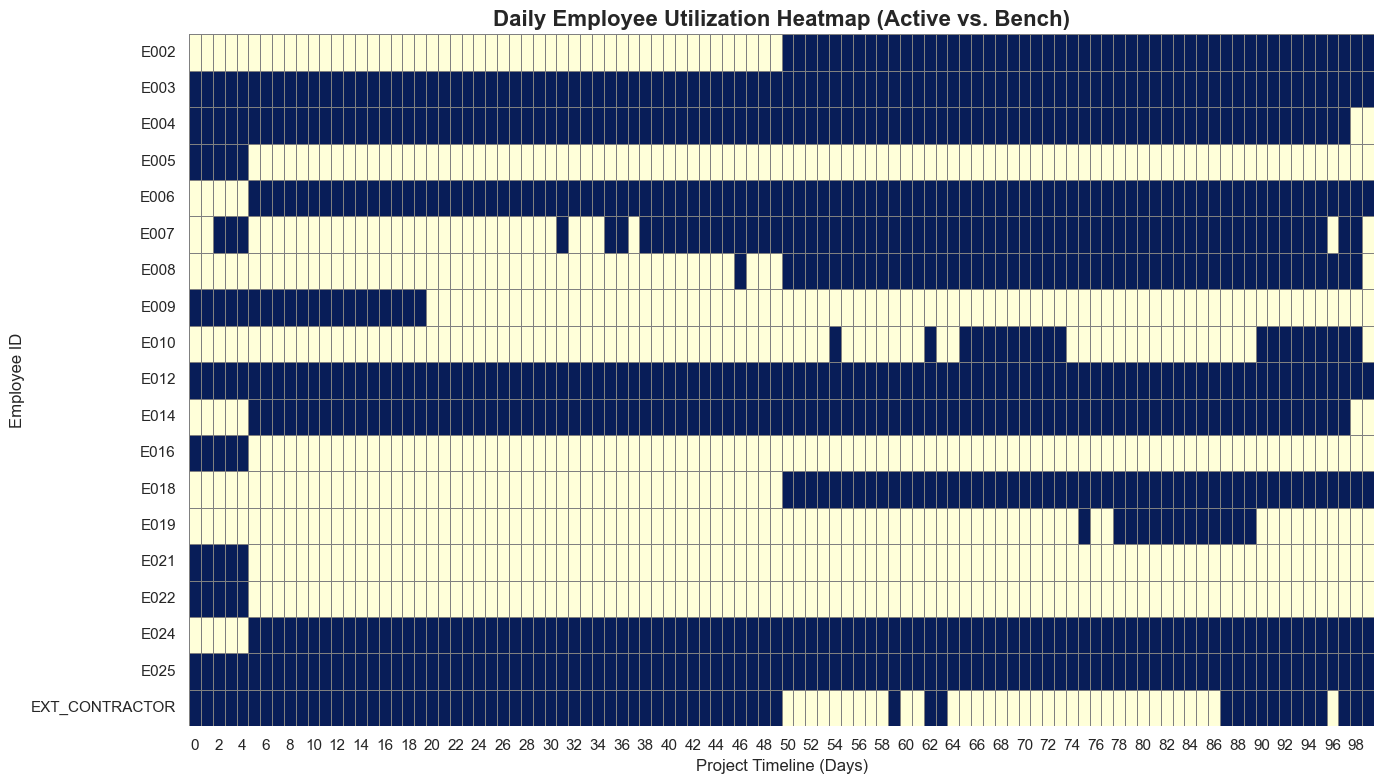

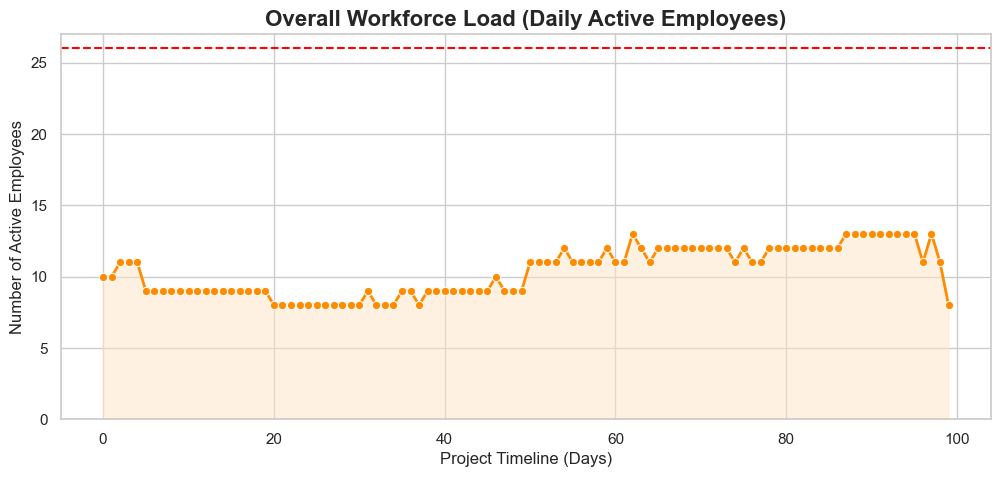

In [22]:
if status == pywraplp.Solver.OPTIMAL:
    print("\nGenerating Utilization Plots...")
    
    # Extract every single day an employee is working
    active_days = []
    for (i, j) in valid_pairs:
        for t in range(TIME_HORIZON):
            if z[(i, j, t)].solution_value() > 0.5:
                active_days.append({
                    'Employee_ID': i, 
                    'Task_ID': j, 
                    'Day': t,
                    'Hours': HOURS_PER_DAY
                })
                
    daily_df = pd.DataFrame(active_days)
    
    # --- PLOT 1: The Resource Heatmap (Schedule Packing) ---
    # This shows EXACTLY what days each employee is busy vs. idle
    plt.figure(figsize=(14, 8))
    
    # Create a pivot table: Rows = Employees, Cols = Days, Values = 1 (Active) or 0 (Idle)
    heatmap_data = daily_df.pivot_table(index='Employee_ID', columns='Day', values='Hours', aggfunc='count', fill_value=0)
    
    # Ensure all days up to Makespan are shown, even if no one is working
    makespan_int = int(C_max.solution_value())
    for day in range(makespan_int):
        if day not in heatmap_data.columns:
            heatmap_data[day] = 0
    heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

    # Plot the heatmap
    sns.heatmap(heatmap_data, cmap="YlGnBu", cbar=False, linewidths=.5, linecolor='gray')
    plt.title('Daily Employee Utilization Heatmap (Active vs. Bench)', fontsize=16, fontweight='bold')
    plt.xlabel('Project Timeline (Days)', fontsize=12)
    plt.ylabel('Employee ID', fontsize=12)
    plt.tight_layout()
    
    heatmap_path = f"{EXPORT_PATH}/utilization_heatmap.png"
    plt.savefig(heatmap_path, dpi=300)
    print(f"📊 Saved Resource Heatmap to: {heatmap_path}")
    plt.show()

    # --- PLOT 2: Daily Burn Rate (Overall Workforce Load) ---
    # This shows how many employees are active concurrently on any given day
    plt.figure(figsize=(12, 5))
    
    daily_active_count = daily_df.groupby('Day')['Employee_ID'].nunique().reset_index()
    daily_active_count.columns = ['Day', 'Active_Employees']
    
    sns.lineplot(data=daily_active_count, x='Day', y='Active_Employees', marker='o', color='darkorange', linewidth=2)
    plt.fill_between(daily_active_count['Day'], daily_active_count['Active_Employees'], color='bisque', alpha=0.5)
    
    plt.title('Overall Workforce Load (Daily Active Employees)', fontsize=16, fontweight='bold')
    plt.xlabel('Project Timeline (Days)', fontsize=12)
    plt.ylabel('Number of Active Employees', fontsize=12)
    plt.ylim(0, len(employees_df) + 1) # Set max Y to total workforce size
    plt.axhline(y=len(employees_df), color='red', linestyle='--', label='Max Workforce Capacity')
    plt